<a href="https://colab.research.google.com/github/ydv-prince/EDA/blob/main/EDA_4_Spotify_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
url = 'https://drive.google.com/uc?id=1JVgy2yXUOREkzRdCeWjep626uvvF94pP'

In [3]:
df = pd.read_csv(url)

In [4]:
df

,Artist,Track Name,Popularity,Duration (ms),Track ID
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA),92,319191,1yeB8MUNeLo9Ek1UEpsyz6
1,Drake,One Dance,91,173986,1zi7xx7UVEFkmKfv06H8x0
2,Drake,IDGAF (feat. Yeat),90,260111,2YSzYUF3jWqb9YP9VXmpjE
3,Drake,First Person Shooter (feat. J. Cole),88,247444,7aqfrAY2p9BUSiupwk3svU
4,Drake,Jimmy Cooks (feat. 21 Savage),88,218364,3F5CgOj3wFlRv51JsHbxhe
...,...,...,...,...,...
435,French Montana,Splash Brothers,44,221863,3fBsEOnzwtlkpS0LxXAZhN
436,Fat Joe,All The Way Up (feat. Infared),64,191900,7Ezwtgfw7khBrpvaNPtMoT
437,A$AP Ferg,"Work REMIX (feat. A$AP Rocky, French Montana, ...",69,283693,7xVLFuuYdAvcTfcP3IG3dS
438,Diddy,Another One Of Me (feat. 21 Savage),65,220408,4hGmQboiou09EwhcTWa0H6


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Artist         440 non-null    object
 1   Track Name     440 non-null    object
 2   Popularity     440 non-null    int64 
 3   Duration (ms)  440 non-null    int64 
 4   Track ID       440 non-null    object
dtypes: int64(2), object(3)
memory usage: 17.3+ KB


In [6]:
df.isnull().values.any()

np.False_

In [7]:
#Q1. Read the dataframe, check null value if present then do the needful, check duplicate row , if present then do the needful.

df.isnull().sum()

,0
Artist,0
Track Name,0
Popularity,0
Duration (ms),0
Track ID,0


In [8]:
df.duplicated().sum()

np.int64(27)

In [9]:
df.shape

(440, 5)

In [10]:
df.drop_duplicates(subset='Track ID', inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Popularity', ylabel='Count'>

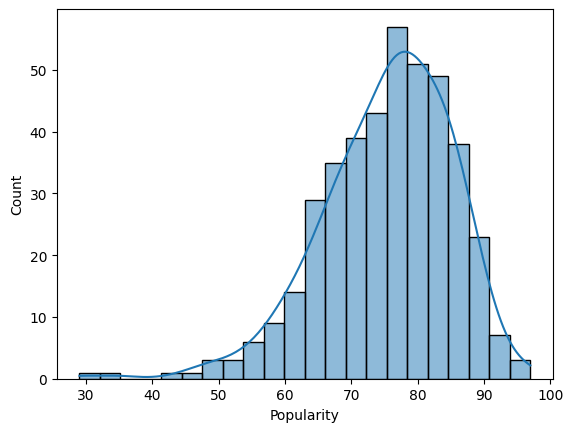

In [12]:
#Q2. What is the distribution of popularity among the tracks in the dataset? Visualize it using a histogram.

sns.histplot(x = 'Popularity', kde = True, data = df, palette = 'muted')

In [13]:
df['Duration'] = df['Duration (ms)']
df.drop('Duration (ms)', axis = 1, inplace = True)

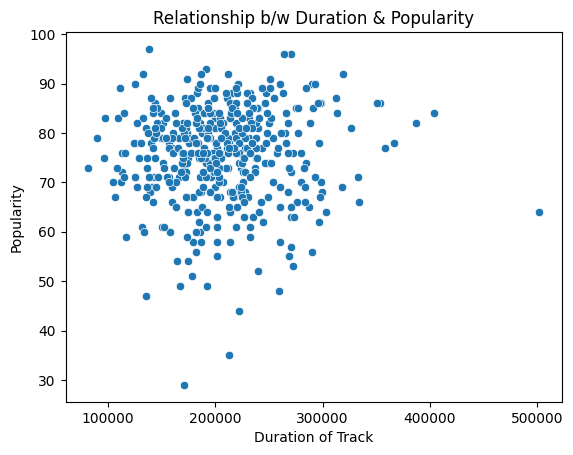

In [14]:
#Q3. Is there any relationship between the popularity and the duration of tracks? Explore this using a scatter plot.

sns.scatterplot(x = 'Duration', y = 'Popularity', data = df, palette = 'Set1')
plt.title('Relationship b/w Duration & Popularity')
plt.xlabel('Duration of Track')
plt.ylabel('Popularity')
plt.show()

In [16]:
#Q4. Which artist has the highest number of tracks in the dataset? Display the count of tracks for each artist using a countplot.

df['Artist'].value_counts().idxmax()

'Drake'

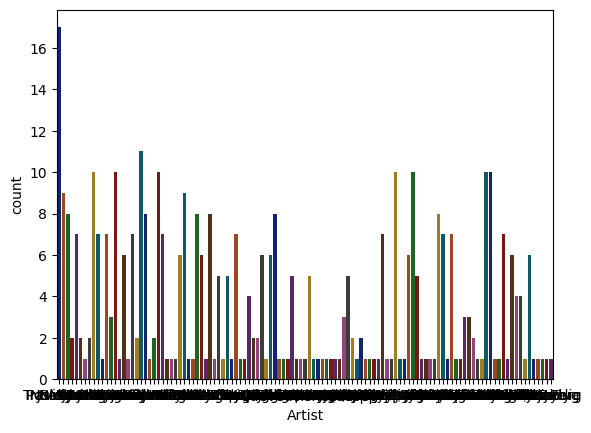

In [17]:
sns.countplot(x = 'Artist', data = df, palette = 'dark')
plt.show()

In [18]:
df.columns

Index(['Artist', 'Track Name', 'Popularity', 'Track ID', 'Duration'], dtype='object')

In [19]:
#Q5. What are the top 5 least popular tracks in the dataset? Provide the artist name and track name for each.

index = df['Popularity'].sort_values(ascending= False).tail().index
df.loc[index, ['Track Name', 'Artist']]

,Track Name,Artist
407,911 (feat. Mary J. Blige),Wyclef Jean
225,On Me - Remix,Lil Baby
413,Splash Brothers,French Montana
231,Intentions,Justin Bieber
207,Attachments (feat. Coi Leray),Pressa


In [15]:
df.columns

Index(['Artist', 'Track Name', 'Popularity', 'Track ID', 'Duration'], dtype='object')

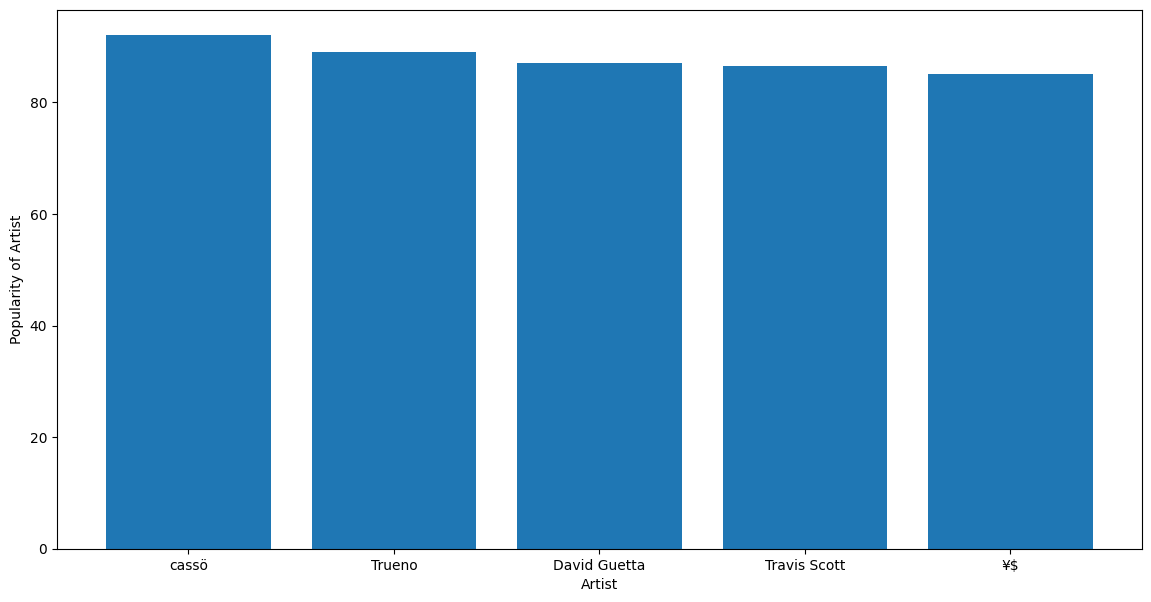

In [60]:
#Q6. Among the top 5 most popular artists, which artist has the highest popularity on average?
# Calculate and display the average popularity for each artist

top_5_artists = (df.groupby('Artist')['Popularity'].mean().sort_values(ascending=False).head(5))

# highest_avg_popularity_artist = top_5_artists.idxmax()  #Artist
# highest_avg_popularity_value = top_5_artists.max()    #Value

plt.figure(figsize=(14,7))
plt.bar(top_5_artists.index, top_5_artists.values)
plt.xlabel('Artist')
plt.ylabel('Popularity of Artist')
plt.show()

In [66]:
# Q7. For the top 5 most popular artists, what are their most popular tracks? List the track name for each artist.

top_5_index = df.groupby('Artist')['Popularity'].mean().sort_values(ascending=False).head(5).index
top_5_df = df[df['Artist'].isin(top_5_index)]
top_5_df[['Artist', 'Track Name']]

,Artist,Track Name
7,Travis Scott,MELTDOWN (feat. Drake)
30,Travis Scott,FE!N (feat. Playboi Carti)
31,Travis Scott,I KNOW ?
32,Travis Scott,MY EYES
33,Travis Scott,goosebumps
37,Travis Scott,SICKO MODE
38,Travis Scott,TELEKINESIS (feat. SZA & Future)
140,cassö,Prada
173,Travis Scott,SKITZO (feat. Young Thug)
200,David Guetta,Baby Don't Hurt Me


Text(0.5, 1.0, 'Pairplot')

<Figure size 1400x700 with 0 Axes>

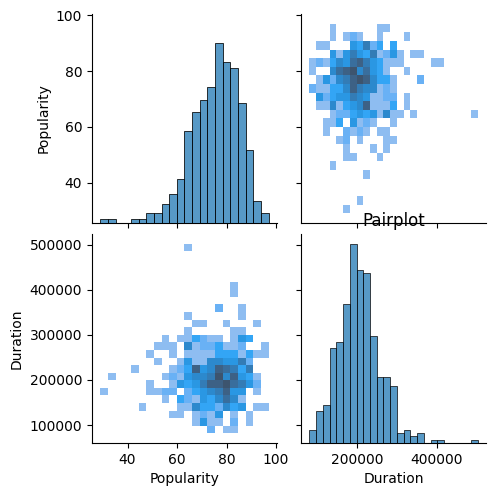

In [77]:
# Q8. Visualize relationships between multiple numerical variables simultaneously using a pair plot.

plt.figure(figsize=(14,7))
sns.pairplot(data = df, palette= 'muted', kind='hist', diag_kind='auto', markers= 'o')
plt.title('Pairplot')

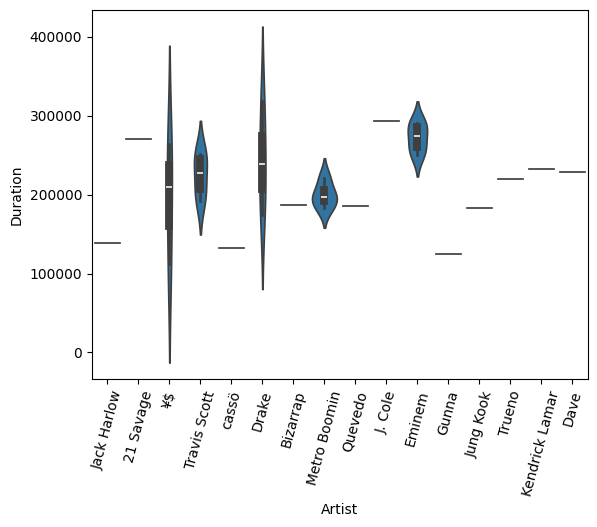

In [93]:
# Q9. Does the duration of tracks vary significantly across different artists? Explore this visually using a box plot or violin plot.

top_30_artist = df.groupby(['Artist', 'Duration'])['Popularity'].mean().sort_values(ascending= False).reset_index().head(30)
sns.violinplot(x = 'Artist', y = 'Duration', data = top_30_artist)
plt.xlabel("Artist")
plt.ylabel("Duration")
plt.xticks(rotation = 75)
plt.show()

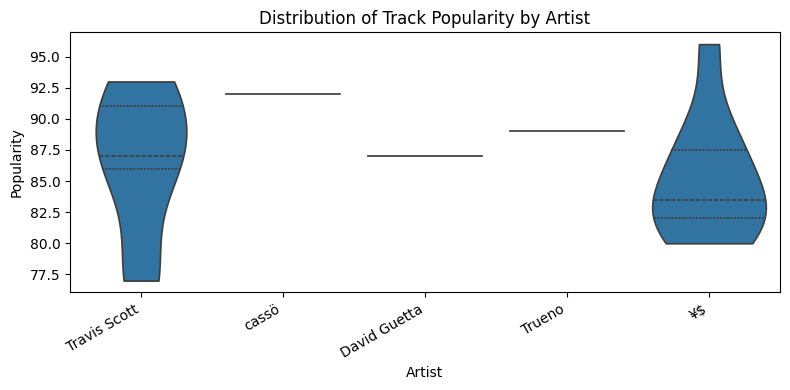

In [103]:
# Q10. How does the distribution of track popularity vary for different artists? Visualize this using a swarm plot or a violin plot

top_artists = (df.groupby('Artist')['Popularity'].mean().sort_values(ascending=False).head(5).index)
top_artists = df[df['Artist'].isin(top_artists)]

plt.figure(figsize=(8, 4))
sns.violinplot(data=top_artists, x='Artist', y='Popularity', inner='quartile', cut=0)
plt.xlabel('Artist')
plt.ylabel('Popularity')
plt.title('Distribution of Track Popularity by Artist')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

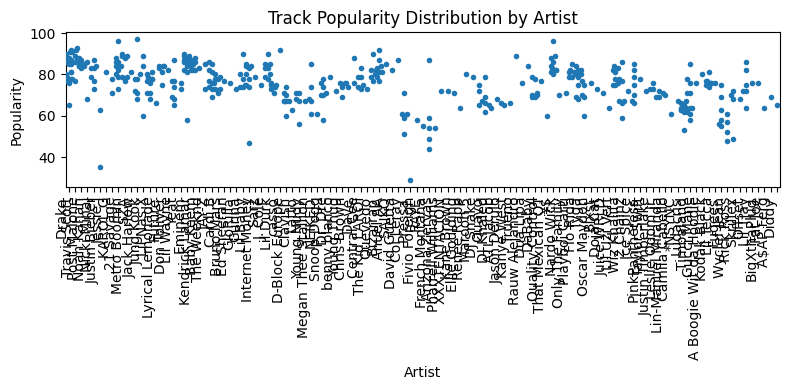

In [104]:
plt.figure(figsize=(8, 4))

sns.swarmplot(data=df, x='Artist', y='Popularity', size=4)
plt.xlabel('Artist')
plt.ylabel('Popularity')
plt.title('Track Popularity Distribution by Artist')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()
